In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge, LinearRegression

findfont: Failed to find font weight normal, now using 700.


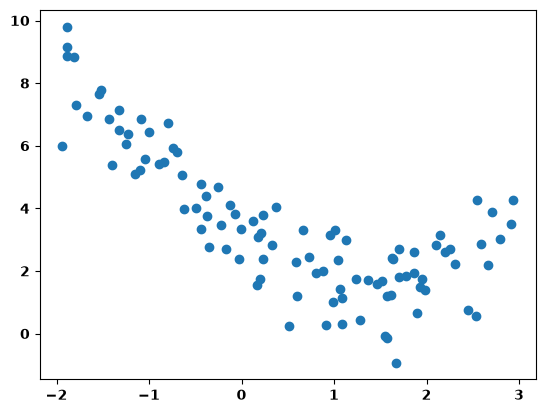

In [2]:

m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

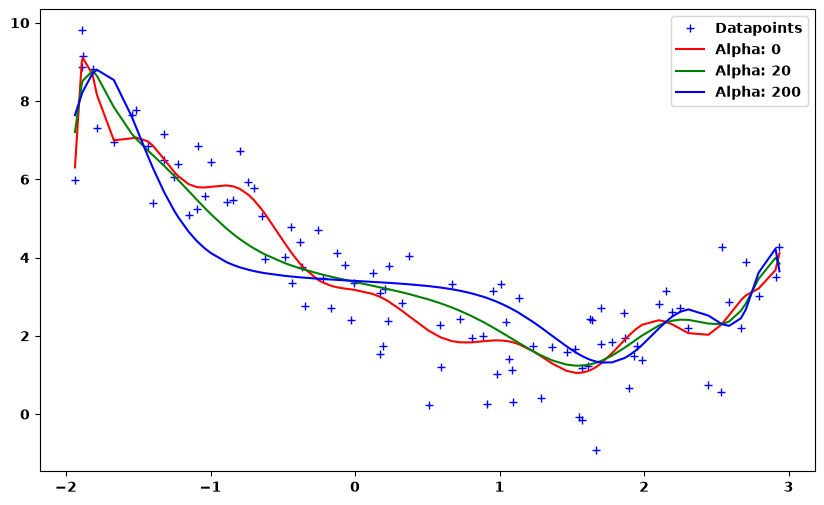

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

In [4]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

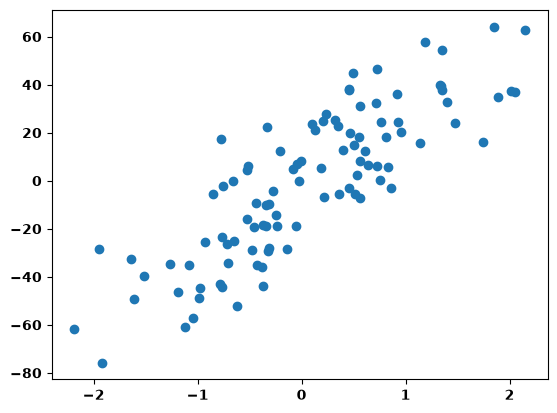

In [5]:
plt.scatter(X,y)

In [6]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [7]:
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.126913003523573


In [8]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


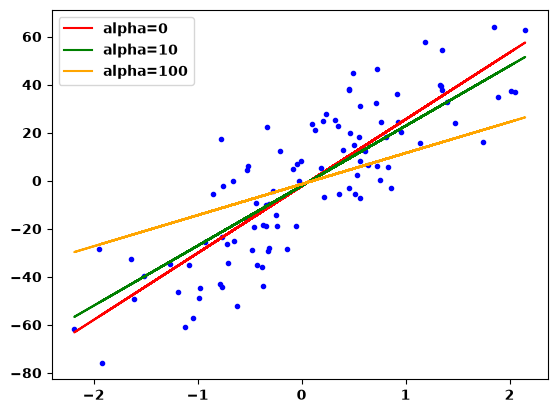

In [9]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha=0')
plt.plot(X,rr.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='orange',label='alpha=100')
plt.legend()

In [13]:
class OwnReidge:

    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        num = 0
        den = 0

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())

            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()) 

        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m , self.b)

    def predict(X_test):
        pass

In [ ]:
reg = OwnReidge(alpha=100 )
reg.fit(X,y)

[12.93442104] [-1.42484415]


Ridge Regression for N-Dimension

In [17]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [18]:
Z, c = load_diabetes(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(Z,c, test_size=0.2, random_state=4)

In [19]:
reg2 = Ridge(alpha=0.1 , solver='cholesky')
reg2.fit(X_train, y_train)

y_pred = reg2.predict(X_test)

r2_score(y_test, y_pred)

0.46931288533098037

In [20]:
print(reg2.coef_)
print(reg2.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [24]:
class NRidge:

    def __init__(self, alpha=0.1):
            self.alpha = alpha
            self.coef_ = None
            self.intercept_ = None
    
    def fit(self, X_train, y_train):
        X_train = np.insert(X_train, 0, 1, axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(X_train.T, X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]

        pass
    
    def predict(self,X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [25]:
reg3 = NRidge()
reg3.fit(X_train, y_train)

y_pred = reg3.predict(X_test)

print(r2_score(y_test, y_pred))
print(reg3.coef_)
print(reg3.intercept_)

0.4693128853309805
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808
